[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AltamarMx/anomalias-2026-2/blob/main/notebooks/011_hipotesis_teoria.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
from IPython.display import display, Markdown

# Pruebas de Hipótesis (Teoría)

**Objetivo:** Formalizar el razonamiento "¿es esta diferencia real o
producto del azar?", entender p-values, errores tipo I/II y por qué
el tamaño del efecto importa tanto como la significancia estadística.

**Temas:**

1. Marco conceptual: H₀ vs H₁
2. Estadístico de prueba y p-value
3. Errores tipo I y tipo II — simulación
4. Tamaño del efecto (Cohen's d)

---
## 1. Marco conceptual

| Concepto | Definición | Analogía (juicio) |
|:---|:---|:---|
| **H₀** (hipótesis nula) | "No hay efecto" / "No hay diferencia" | El acusado es inocente |
| **H₁** (hipótesis alternativa) | "Sí hay efecto" / "Las medias difieren" | El acusado es culpable |
| **Rechazar H₀** | La evidencia es suficiente para concluir que hay efecto | Veredicto: culpable |
| **No rechazar H₀** | No hay evidencia suficiente (no significa que H₀ sea cierta) | Veredicto: no culpable (≠ inocente) |

El proceso:

1. Plantear H₀ y H₁
2. Recoger datos y calcular un **estadístico de prueba**
3. Calcular el **p-value**: probabilidad de observar un estadístico
   tan extremo (o más) si H₀ fuera cierta
4. Si p < α (típicamente 0.05), **rechazar H₀**

---
## 2. Estadístico de prueba y p-value

Para comparar las medias de dos grupos, el **estadístico t** mide
cuántas "desviaciones estándar" separan las medias muestrales:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

donde $s_p$ es la desviación estándar combinada (pooled).

Si H₀ es cierta ($\mu_1 = \mu_2$), entonces $t$ sigue una distribución
$t$ de Student. Valores grandes de $|t|$ son evidencia contra H₀.

El **p-value** es el área en las colas más allá de $|t|$:

### Visualización interactiva

In [2]:
t_obs_slider = widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=2.0, description="t observado")
gl_slider = widgets.IntSlider(min=5, max=100, step=5, value=30, description="Grados de libertad")

def _update(t_obs_slider, gl_slider):
    _t_obs = t_obs_slider
    _gl = gl_slider
    _p_value = 2 * stats.t.sf(abs(_t_obs), _gl)

    fig1, ax1 = plt.subplots(figsize=(9, 4))

    _x = np.linspace(-5, 5, 500)
    _pdf = stats.t.pdf(_x, _gl)
    ax1.plot(_x, _pdf, "k-", lw=2)

    # Región de rechazo (colas)
    _mask_left = _x <= -abs(_t_obs)
    _mask_right = _x >= abs(_t_obs)
    ax1.fill_between(_x[_mask_left], _pdf[_mask_left],
                     color="crimson", alpha=0.4, label=f"p-value = {_p_value:.4f}")
    ax1.fill_between(_x[_mask_right], _pdf[_mask_right],
                     color="crimson", alpha=0.4)

    # Región central
    _mask_center = (_x > -abs(_t_obs)) & (_x < abs(_t_obs))
    ax1.fill_between(_x[_mask_center], _pdf[_mask_center],
                     color="steelblue", alpha=0.15)

    ax1.axvline(_t_obs, color="crimson", ls="--", lw=1.5)
    ax1.axvline(-_t_obs, color="crimson", ls="--", lw=1.5)

    _decision = "Rechazar H₀ ✓" if _p_value < 0.05 else "No rechazar H₀"
    ax1.set_title(
        f"Distribución t (gl = {_gl})  —  t = ±{_t_obs:.1f}  —  "
        f"p = {_p_value:.4f}  →  {_decision}"
    )
    ax1.set_xlabel("t")
    ax1.set_ylabel("Densidad")
    ax1.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(_update, {'t_obs_slider': t_obs_slider, 'gl_slider': gl_slider})
display(widgets.VBox([t_obs_slider, gl_slider, out]))

> **Experimenta:**
> - Con $t = 2.0$ y $gl = 30$, $p \approx 0.05$ — justo en el límite.
> - Sube $t$ a 3.0: $p$ se vuelve muy pequeño — evidencia fuerte.
> - Baja $t$ a 1.0: $p > 0.30$ — no hay evidencia para rechazar H₀.
> - Cambia los grados de libertad: con pocos gl, necesitas un $t$ más
>   grande para el mismo p-value (colas más pesadas).

---
## 3. Errores tipo I y tipo II

| | H₀ es cierta | H₀ es falsa |
|:---|:---:|:---:|
| **No rechazar H₀** | ✓ Correcto | **Error tipo II** (falso negativo, β) |
| **Rechazar H₀** | **Error tipo I** (falso positivo, α) | ✓ Correcto (poder = 1−β) |

- **Error tipo I:** Decir que hay diferencia cuando no la hay.
  Controlado por $\alpha$ (típicamente 0.05).
- **Error tipo II:** No detectar una diferencia real.
  Depende de $n$, del tamaño del efecto y de $\alpha$.

### 3.1 Error tipo I — simulación

Si H₀ es cierta (ambos grupos vienen de la *misma* distribución),
¿con qué frecuencia rechazamos H₀ por puro azar?

Generamos 1,000 pares de muestras de $N(25, 5^2)$, aplicamos la
prueba t, y contamos cuántas veces $p < 0.05$.

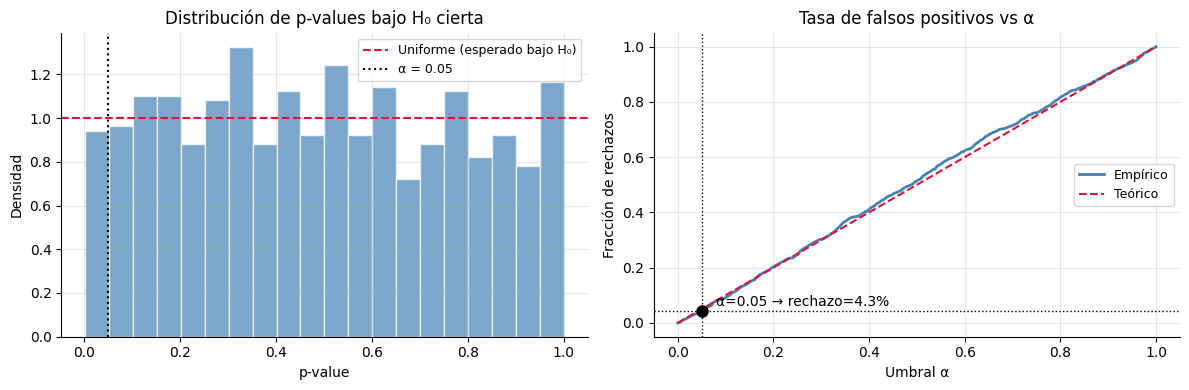

In [3]:
_mu, _sigma = 25.0, 5.0
_n = 30
_num_sim = 1000

_p_values = np.zeros(_num_sim)
for i in range(_num_sim):
    _a = rng.normal(_mu, _sigma, _n)
    _b = rng.normal(_mu, _sigma, _n)
    _, _p_values[i] = stats.ttest_ind(_a, _b)

_tasa_rechazo = (_p_values < 0.05).mean()

fig3a, (ax3a1, ax3a2) = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de p-values
ax3a1.hist(_p_values, bins=20, density=True, color="steelblue",
           alpha=0.7, edgecolor="white")
ax3a1.axhline(1.0, color="crimson", ls="--", lw=1.5,
              label="Uniforme (esperado bajo H₀)")
ax3a1.axvline(0.05, color="black", ls=":", lw=1.5, label="α = 0.05")
ax3a1.set_xlabel("p-value")
ax3a1.set_ylabel("Densidad")
ax3a1.set_title("Distribución de p-values bajo H₀ cierta")
ax3a1.legend(fontsize=9)

# Fracción acumulada de rechazos
_alphas = np.linspace(0, 1, 200)
_rechazos = [(_p_values < a).mean() for a in _alphas]
ax3a2.plot(_alphas, _rechazos, "steelblue", lw=2, label="Empírico")
ax3a2.plot([0, 1], [0, 1], "crimson", ls="--", lw=1.5, label="Teórico")
ax3a2.axvline(0.05, color="black", ls=":", lw=1)
ax3a2.axhline(_tasa_rechazo, color="black", ls=":", lw=1)
ax3a2.plot(0.05, _tasa_rechazo, "ko", markersize=8)
ax3a2.text(0.08, _tasa_rechazo + 0.02,
           f"α=0.05 → rechazo={_tasa_rechazo:.1%}", fontsize=10)
ax3a2.set_xlabel("Umbral α")
ax3a2.set_ylabel("Fracción de rechazos")
ax3a2.set_title("Tasa de falsos positivos vs α")
ax3a2.legend(fontsize=9)

plt.tight_layout()
plt.show()

> **Resultado clave:**
> - Bajo H₀ cierta, los p-values se distribuyen **uniformemente** entre 0 y 1.
> - Exactamente ~5% caen por debajo de 0.05 → eso es el error tipo I.
> - Si haces 20 pruebas, espera 1 resultado "significativo" por azar.

### 3.2 Error tipo II y poder estadístico

Ahora H₀ es **falsa**: un grupo tiene $\mu_1 = 25$ y el otro
$\mu_2 = 25 + \delta$.  ¿Con qué frecuencia logramos detectar
la diferencia?

El **poder** = $1 - \beta$ = probabilidad de rechazar H₀ cuando
es falsa.  Depende de:
- $\delta$ (tamaño del efecto): más fácil detectar diferencias grandes
- $n$ (tamaño de muestra): más datos = más poder
- $\alpha$: umbral más laxo = más poder pero más falsos positivos

In [4]:
delta_slider = widgets.FloatSlider(min=0.0, max=5.0, step=0.5, value=1.0, description="δ (diferencia real entre medias)",
)

def _update(delta_slider):
    _delta = delta_slider
    _mu1 = 25.0
    _mu2 = _mu1 + _delta
    _sigma = 5.0
    _num_sim = 1000

    _ns = [10, 20, 50, 100, 200]
    _poderes = []

    for _n in _ns:
        _rechazos = 0
        for _ in range(_num_sim):
            _a = rng.normal(_mu1, _sigma, _n)
            _b = rng.normal(_mu2, _sigma, _n)
            _, _p = stats.ttest_ind(_a, _b)
            if _p < 0.05:
                _rechazos += 1
        _poderes.append(_rechazos / _num_sim)

    fig3b, ax3b = plt.subplots(figsize=(8, 5))
    ax3b.plot(_ns, _poderes, "o-", color="steelblue", lw=2, markersize=8)
    ax3b.axhline(0.8, color="seagreen", ls="--", lw=1.5,
                 label="Poder = 80% (convención)")
    ax3b.axhline(0.05, color="crimson", ls=":", lw=1.5,
                 label="α = 5% (falso positivo si δ=0)")
    ax3b.set_xlabel("Tamaño de muestra (n por grupo)")
    ax3b.set_ylabel("Poder (1 − β)")
    ax3b.set_title(
        f"Poder estadístico vs n  —  δ = {_delta:.1f},  σ = {_sigma}"
    )
    ax3b.set_ylim(-0.02, 1.05)
    ax3b.legend()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(_update, {'delta_slider': delta_slider})
display(widgets.VBox([delta_slider, out]))

> **Experimenta con el slider:**
> - $\delta = 0$: el poder es ~5% (= α), porque no hay efecto real
>   → rechazos son falsos positivos.
> - $\delta = 1$ (efecto pequeño): con $n = 10$ el poder es bajísimo
>   (~10–15%); con $n = 200$ alcanza ~80%.
> - $\delta = 3$ (efecto grande): incluso $n = 20$ tiene buen poder.
>
> **Lección:** Con muestras pequeñas, solo detectamos efectos grandes.
> Las diferencias sutiles requieren muchos datos.

---
## 4. Tamaño del efecto — Cohen's d

El p-value responde "¿hay diferencia?" pero no "¿qué tan grande es?".

**Cohen's d** mide la diferencia en unidades de desviación estándar:

$$d = \frac{|\bar{x}_1 - \bar{x}_2|}{s_p}$$

| d | Interpretación |
|:---|:---|
| 0.2 | Efecto pequeño |
| 0.5 | Efecto mediano |
| 0.8 | Efecto grande |

**Problema con muestras grandes:** Con millones de datos, cualquier
diferencia por mínima que sea produce p ≈ 0.  El p-value ya no
discrimina — necesitamos Cohen's d.

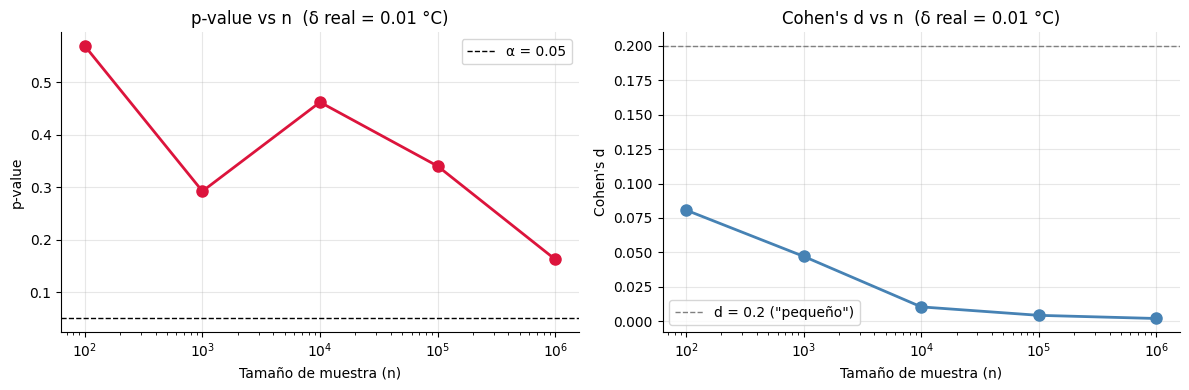

In [5]:
_sigma = 5.0
_delta = 0.01  # Diferencia real de 0.01 °C
_ns = [100, 1_000, 10_000, 100_000, 1_000_000]

_p_values = []
_cohens_d = []

for _n in _ns:
    _a = rng.normal(25.0, _sigma, _n)
    _b = rng.normal(25.0 + _delta, _sigma, _n)
    _, _p = stats.ttest_ind(_a, _b)
    _sp = np.sqrt((_a.var(ddof=1) + _b.var(ddof=1)) / 2)
    _d = abs(_a.mean() - _b.mean()) / _sp
    _p_values.append(_p)
    _cohens_d.append(_d)

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(12, 4))

ax4a.plot(_ns, _p_values, "o-", color="crimson", lw=2, markersize=8)
ax4a.axhline(0.05, color="black", ls="--", lw=1, label="α = 0.05")
ax4a.set_xscale("log")
ax4a.set_xlabel("Tamaño de muestra (n)")
ax4a.set_ylabel("p-value")
ax4a.set_title(f"p-value vs n  (δ real = {_delta} °C)")
ax4a.legend()

ax4b.plot(_ns, _cohens_d, "o-", color="steelblue", lw=2, markersize=8)
ax4b.axhline(0.2, color="gray", ls="--", lw=1, label='d = 0.2 ("pequeño")')
ax4b.set_xscale("log")
ax4b.set_xlabel("Tamaño de muestra (n)")
ax4b.set_ylabel("Cohen's d")
ax4b.set_title(f"Cohen's d vs n  (δ real = {_delta} °C)")
ax4b.legend()

plt.tight_layout()
plt.show()

> **Mensaje clave:**
>
> - Con $n = 1{,}000{,}000$, el p-value es minúsculo para una
>   diferencia de **0.01 °C** — "estadísticamente significativa"
>   pero completamente **irrelevante** en la práctica.
> - Cohen's d permanece ~0.002 (efecto despreciable) sin importar $n$.
> - **Siempre reporta el tamaño del efecto junto al p-value.**
>   El p-value dice "¿detecté algo?"; Cohen's d dice "¿importa?".

---
## Resumen

| Concepto | Idea clave |
|:---|:---|
| **H₀ / H₁** | H₀ = "no hay efecto"; se rechaza solo con evidencia suficiente |
| **p-value** | Prob. de observar datos tan extremos si H₀ fuera cierta; p < α → rechazar |
| **Error tipo I** | Rechazar H₀ cuando es cierta; ocurre con frecuencia α (~5%) |
| **Error tipo II** | No rechazar H₀ cuando es falsa; depende de n y del tamaño del efecto |
| **Poder** | 1 − β; crece con n y con el tamaño del efecto |
| **Cohen's d** | Mide *cuánto* difieren los grupos; complemento esencial del p-value |

**Próxima sesión (6B):** Aplicar pruebas t a preguntas reales con
ClimaLab: ¿difiere la temperatura entre día y noche? ¿El viento
cambia entre estaciones?